In [1]:

# ── Load results (handles both single-file and sharded output) ──────────────
import glob
import numpy as np
import pandas as pd

from plot_style import order_methods   # canonical method colours/labels/order

OUTPUT_CSV = "./results/results_dp_sbm_sparse_n500.csv"   # match OUTPUT_CSV in script_sparse_synthetic_graph.py

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

# Fixed display order: dense-ish regime first, then the hard sparse one.
REGIME_ORDER = ["relatively_sparse", "sparse"]
REGIME_LABEL = {
    "relatively_sparse": r"relatively sparse  ($p=\log n/n$)",
    "sparse":            r"sparse  ($p=5/n$)",
}
regimes = [r for r in REGIME_ORDER if r in set(df["regime"])]

# ── Baseline vs DP methods ─────────────────────────────────────────────────
# "spectral" is sklearn SpectralClustering fit on the true (unperturbed) LCC
# adjacency -- no privacy at all, so the script records epsilon = inf for it.
# It gets its own box in every epsilon group, exactly like the DP methods,
# which needs one fix-up: with epsilon = inf it would never land in an
# epsilon group, so epsilon_plot re-attaches each spectral row to the epsilon
# its sigma produced. Its boxes are therefore IDENTICAL across the epsilon
# axis by construction -- within a rep the graph does not depend on sigma --
# and that flatness is the point: it reads as the non-private ceiling the DP
# boxes are being compared against.
#
# Colours and display names come from plot_style.py (shared with every other
# analysis notebook), so a method keeps its colour across the whole thesis.
BASELINE_METHOD = "spectral"
DP_METHODS = order_methods(m for m in df["method"].unique() if m != BASELINE_METHOD)
HAS_BASELINE = BASELINE_METHOD in set(df["method"])
METHOD_ORDER = DP_METHODS + ([BASELINE_METHOD] if HAS_BASELINE else [])

eps_by_sigma = (df[np.isfinite(df["epsilon"])]
                  .groupby(["regime", "sigma"])["epsilon"].first())
df["epsilon_plot"] = np.where(
    np.isfinite(df["epsilon"]),
    df["epsilon"],
    pd.MultiIndex.from_frame(df[["regime", "sigma"]]).map(eps_by_sigma),
)

# Deduped baseline (one row per graph) for the summary tables: the identical
# spectral row is written once per sigma, so keeping every copy would repeat
# each value len(SIGMAS) times and make its spread look artificially tight.
# (The plots do NOT need this -- within a single epsilon group there is
# already exactly one spectral row per rep.)
base = (df[df["method"] == BASELINE_METHOD]
          .drop_duplicates(subset=["regime", "rep"])
          .copy())
base["intra_est"] = base[["beta_est_00", "beta_est_11"]].mean(axis=1)
if not HAS_BASELINE:
    print(f"NOTE: no '{BASELINE_METHOD}' rows found -- the baseline will be absent from the plots.")

# Sanity table: what graphs did we actually get, and how many nodes were fit?
# n_fit (= lcc_size) is the node count every method actually saw: the script
# fits and scores on the largest connected component only.
summary = (df.groupby("regime")
             .agg(N=("N", "first"), p=("p", "first"), q=("q", "first"),
                  mean_degree=("mean_degree", "mean"),
                  n_fit_mean=("n_fit", "mean"),
                  lcc_frac_mean=("lcc_frac", "mean"),
                  n_sigmas=("sigma", "nunique"), n_reps=("rep", "nunique"),
                  rows=("nmi", "size")))
display(summary.reindex(regimes).round(4))
print("methods plotted:", METHOD_ORDER)
df.head()

Loaded ./results/results_dp_sbm_sparse_n500.csv, 600 rows.


,N,p,q,mean_degree,n_fit_mean,lcc_frac_mean,n_sigmas,n_reps,rows
regime,,,,,,,,,
relatively_sparse,500,0.0124,0.0012,3.4112,481.40,0.9628,5,20,300
sparse,500,0.0100,0.0010,2.7260,459.75,0.9195,5,20,300


methods plotted: ['edge_flip_vem', 'sbm_dpsgd_all_noised', 'spectral']


,regime,N,p,q,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,...,n_components,n_isolated,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi,epsilon_plot
0,relatively_sparse,500,0.012429,0.001243,0.5,inf,0,spectral,NaN,NaN,...,15,13,0.012429,0.001243,0.012429,0.007206,0.000348,0.333333,0.022440,75.261074
1,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,0,edge_flip_vem,NaN,NaN,...,15,13,0.012429,0.001243,0.012429,0.007080,0.000000,0.000000,0.000000,75.261074
2,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,0,sbm_dpsgd_all_noised,70.772185,12.423129,...,15,13,0.012429,0.001243,0.012429,0.109132,0.006115,0.118728,0.000873,75.261074
3,relatively_sparse,500,0.012429,0.001243,0.5,inf,1,spectral,NaN,NaN,...,20,18,0.012429,0.001243,0.012429,0.013379,0.001316,0.015484,0.575148,75.261074
4,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,1,edge_flip_vem,NaN,NaN,...,20,18,0.012429,0.001243,0.012429,0.000000,0.000000,0.007818,0.000000,75.261074


,n_graphs,mean_degree,n_fit_mean,lcc_frac_mean,lcc_frac_min,lcc_frac_max,n_components,n_isolated
regime,,,,,,,,
relatively_sparse,20,3.4112,481.40,0.9628,0.946,0.976,18.40,16.35
sparse,20,2.7260,459.75,0.9195,0.896,0.942,37.15,32.65


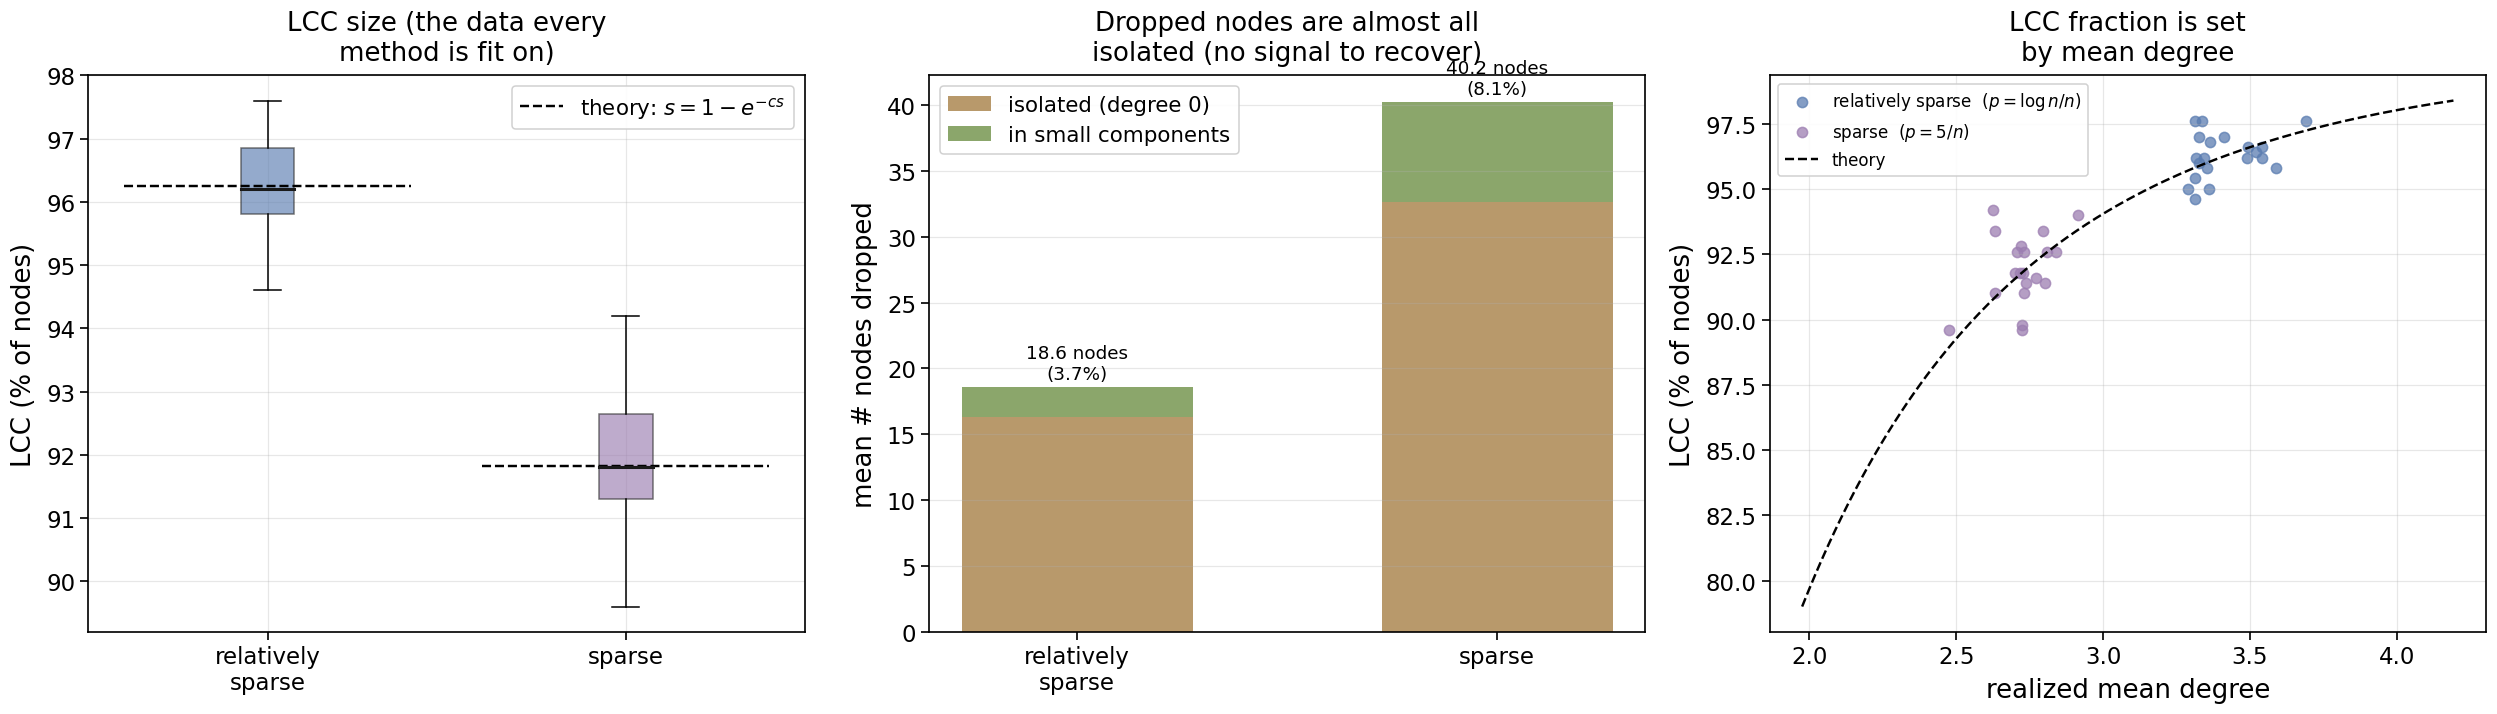

mean % of nodes actually fit / scored:   relatively_sparse = 96.3%   sparse = 92.0%


In [2]:
# ── Connectivity of the generated graphs ───────────────────────────────────
# These columns describe the FULL drawn graph, BEFORE the largest connected
# component is extracted. Every method is then fit and scored on the LCC
# alone (n_fit = lcc_size nodes), so this cell says how much of each draw
# survived into the analysis -- and, equivalently, how much was discarded.
#
# Dedup note: the rep seed depends on (regime, rep) only, NOT on sigma, so
# the same graph is reused across every sigma and all three methods. Without
# the drop_duplicates below, each graph would be counted 3*len(SIGMAS) times
# and the distributions would look far tighter than they are.
#
# These panels describe the DATA, not the methods, so they use neutral
# per-regime colours rather than the per-method palette.
import numpy as np
import matplotlib.pyplot as plt

from plot_style import apply_style, figsize, MEDIAN_COLOR

apply_style()

graphs = df.drop_duplicates(subset=["regime", "rep"])[
    ["regime", "rep", "N", "n_fit", "mean_degree", "lcc_size", "lcc_frac",
     "n_components", "n_isolated"]
].copy()
graphs["non_lcc"] = graphs["N"] - graphs["lcc_size"]

stats = (graphs.groupby("regime")
               .agg(n_graphs=("rep", "size"),
                    mean_degree=("mean_degree", "mean"),
                    n_fit_mean=("n_fit", "mean"),
                    lcc_frac_mean=("lcc_frac", "mean"),
                    lcc_frac_min=("lcc_frac", "min"),
                    lcc_frac_max=("lcc_frac", "max"),
                    n_components=("n_components", "mean"),
                    n_isolated=("n_isolated", "mean"))
               .reindex(regimes).round(4))
display(stats)

C_REGIME = ["#5B7DB1", "#9C7EB1"]      # one per regime
C_ISOLATED, C_SMALLCOMP = "#B18E5B", "#7E9C5B"

fig, axes = plt.subplots(1, 3, figsize=figsize(17, 5.0))

# (a) LCC fraction -- boxplot per regime, with the theoretical giant-component
#     fraction s solving s = 1 - exp(-c*s) drawn as a reference line.
ax = axes[0]
data = [graphs[graphs["regime"] == r]["lcc_frac"].values * 100 for r in regimes]
bp = ax.boxplot(data, patch_artist=True,
                labels=[r.replace("_", "\n") for r in regimes],
                medianprops=dict(color=MEDIAN_COLOR, linewidth=2.0))
for patch, i in zip(bp["boxes"], range(len(data))):
    patch.set_facecolor(C_REGIME[i % len(C_REGIME)])
    patch.set_alpha(0.65)
    patch.set_edgecolor("#333333")
for i, r in enumerate(regimes):
    c = graphs[graphs["regime"] == r]["mean_degree"].mean()
    if c > 1:                      # supercritical: solve s = 1 - exp(-c s)
        s = 0.5
        for _ in range(200):
            s = 1 - np.exp(-c * s)
        ax.plot([i + 0.6, i + 1.4], [s * 100, s * 100], color="black",
                linestyle="--", linewidth=1.6,
                label="theory: $s=1-e^{-cs}$" if i == 0 else None)
ax.set_ylabel("LCC (% of nodes)")
ax.set_title("LCC size (the data every\nmethod is fit on)")
ax.grid(alpha=0.3)
ax.legend()

# (b) where the DISCARDED nodes go: isolated vs in small components
ax = axes[1]
x = np.arange(len(regimes))
iso = [graphs[graphs["regime"] == r]["n_isolated"].mean() for r in regimes]
rest = [graphs[graphs["regime"] == r]["non_lcc"].mean() - i for r, i in zip(regimes, iso)]
ax.bar(x, iso, 0.55, label="isolated (degree 0)", color=C_ISOLATED, alpha=0.9)
ax.bar(x, rest, 0.55, bottom=iso, label="in small components",
       color=C_SMALLCOMP, alpha=0.9)
for xi, (a, b) in enumerate(zip(iso, rest)):
    ax.text(xi, a + b + 0.6, f"{a + b:.1f} nodes\n({(a + b) / graphs['N'].iloc[0]:.1%})",
            ha="center", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([r.replace("_", "\n") for r in regimes])
ax.set_ylabel("mean # nodes dropped")
ax.set_title("Dropped nodes are almost all\nisolated (no signal to recover)")
ax.grid(alpha=0.3, axis="y")
ax.legend()

# (c) LCC fraction vs realized mean degree -- the driver of everything above
ax = axes[2]
for i, r in enumerate(regimes):
    g = graphs[graphs["regime"] == r]
    ax.scatter(g["mean_degree"], g["lcc_frac"] * 100, s=45, alpha=0.75,
               color=C_REGIME[i % len(C_REGIME)], label=REGIME_LABEL[r])
cc = np.linspace(max(1.01, graphs["mean_degree"].min() - 0.5),
                 graphs["mean_degree"].max() + 0.5, 200)
ss = np.full_like(cc, 0.5)
for _ in range(200):
    ss = 1 - np.exp(-cc * ss)
ax.plot(cc, ss * 100, color="black", linestyle="--", linewidth=1.6, label="theory")
ax.set_xlabel("realized mean degree")
ax.set_ylabel("LCC (% of nodes)")
ax.set_title("LCC fraction is set\nby mean degree")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Scope reminder: because the fit and the scoring both happen on the LCC,
# NMI = 1 is attainable in principle (no isolated-node penalty is baked in),
# but every number in this notebook is conditional on the LCC -- it says
# nothing about the ~4-8% of nodes that were dropped.
print("mean % of nodes actually fit / scored:   "
      + "   ".join(f"{r} = {graphs[graphs['regime'] == r]['lcc_frac'].mean():.1%}"
                   for r in regimes))

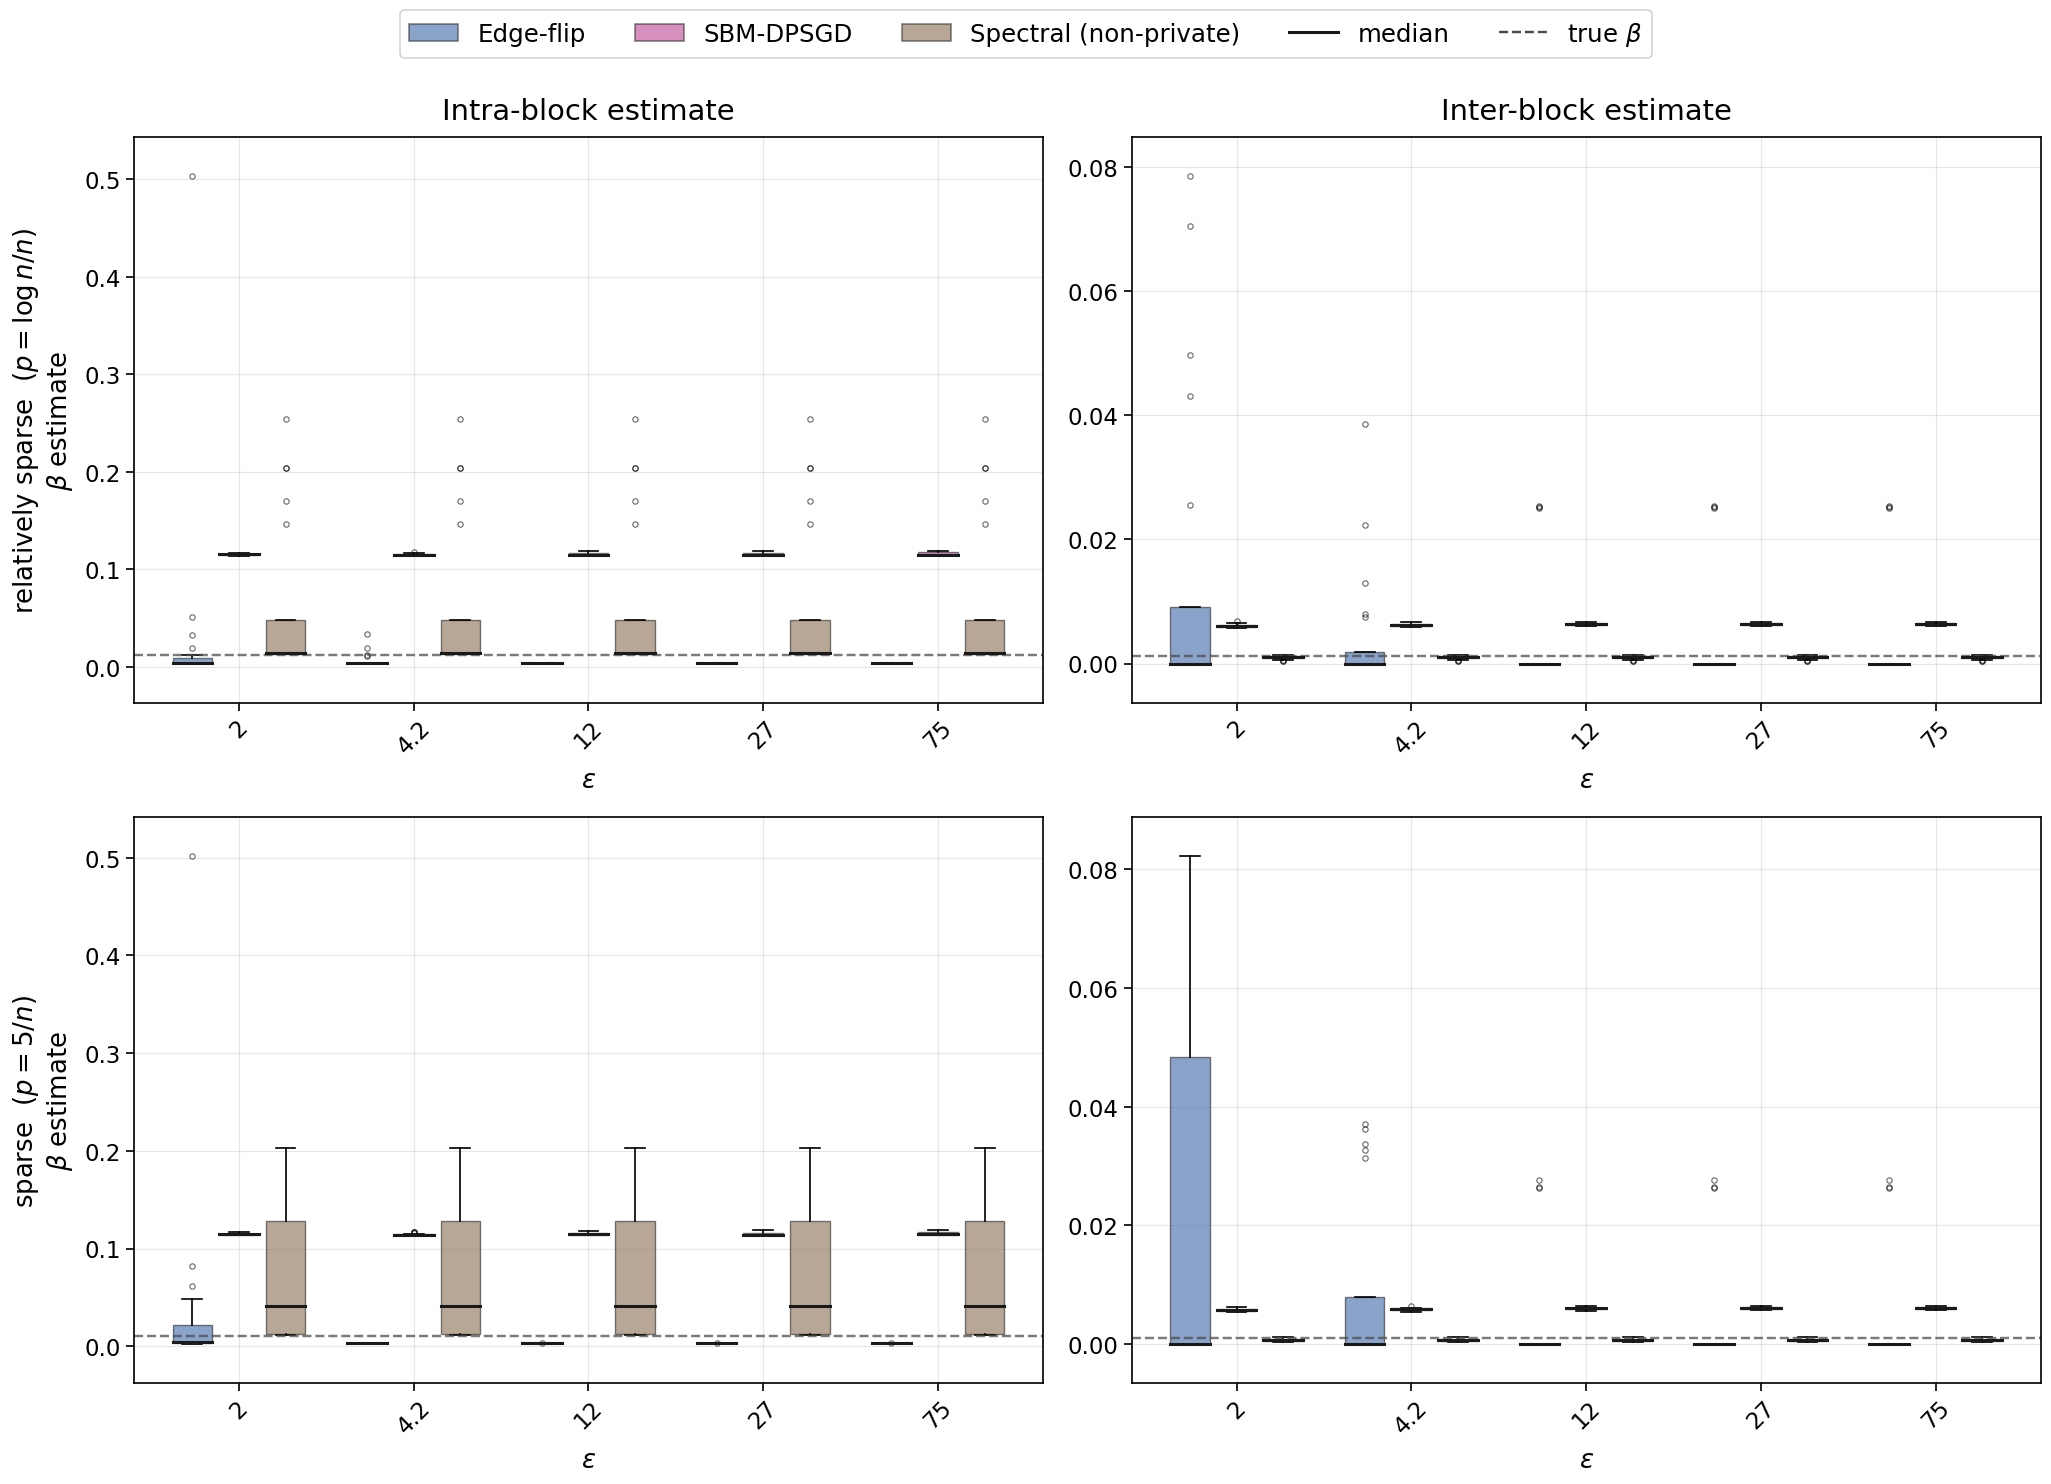

In [3]:

# ── Boxplots of estimated beta vs epsilon ──────────────────────────────────
# Layout: one ROW per sparsity regime (the sweep axis in this notebook, in
# place of N), two COLUMNS (intra-block, inter-block) -- large panels sized
# for a thesis figure. This is the transpose of the earlier layout, matching
# the row-per-N figures in the other notebooks.
#
# All three methods get a box per epsilon group. The spectral baseline is
# non-private, so its epsilon is inf and it is positioned by epsilon_plot (see
# the loader cell): its boxes repeat unchanged across the axis, which is what
# a fixed non-private reference should look like.
#
# NOTE: y-limits are PER PANEL, not shared down a column -- the two regimes
# have different true betas (0.0124 vs 0.0100) and very different estimator
# spread, so a shared scale would flatten one of them.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = METHOD_ORDER

# Per-panel inches before FIG_SCALE -- the single knob for retuning size.
PANEL_W, PANEL_H = 7.0, 5.0

fig, axes = plt.subplots(
    len(regimes), 2,
    figsize=figsize(PANEL_W * 2, PANEL_H * len(regimes)),
    squeeze=False,
)

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

COLUMNS = [
    ("intra_est",   "beta_true_00", "Intra-block estimate"),
    ("beta_est_01", "beta_true_01", "Inter-block estimate"),
]

for row, regime in enumerate(regimes):
    sub = df[df["regime"] == regime].copy()
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)
    eps_vals = sorted(sub["epsilon_plot"].unique())

    for col, (est_col, true_col, col_title) in enumerate(COLUMNS):
        ax = axes[row, col]
        true_val = sub[true_col].iloc[0]
        grouped_boxplot(ax, sub, est_col, x_col="epsilon_plot",
                        methods=methods, x_values=eps_vals)
        reference_line(ax, true_val)

        vals = sub[est_col].dropna()
        ax.set_ylim(*pad(min(vals.min(), true_val), max(vals.max(), true_val)))
        ax.set_xlabel(r"$\epsilon$")
        if row == 0:
            ax.set_title(col_title, fontsize=19, pad=12)

    # The regime labels the row, stated once on the left.
    axes[row, 0].set_ylabel(f"{REGIME_LABEL[regime]}\n" r"$\beta$ estimate",
                            fontsize=17)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label=r"true $\beta$"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

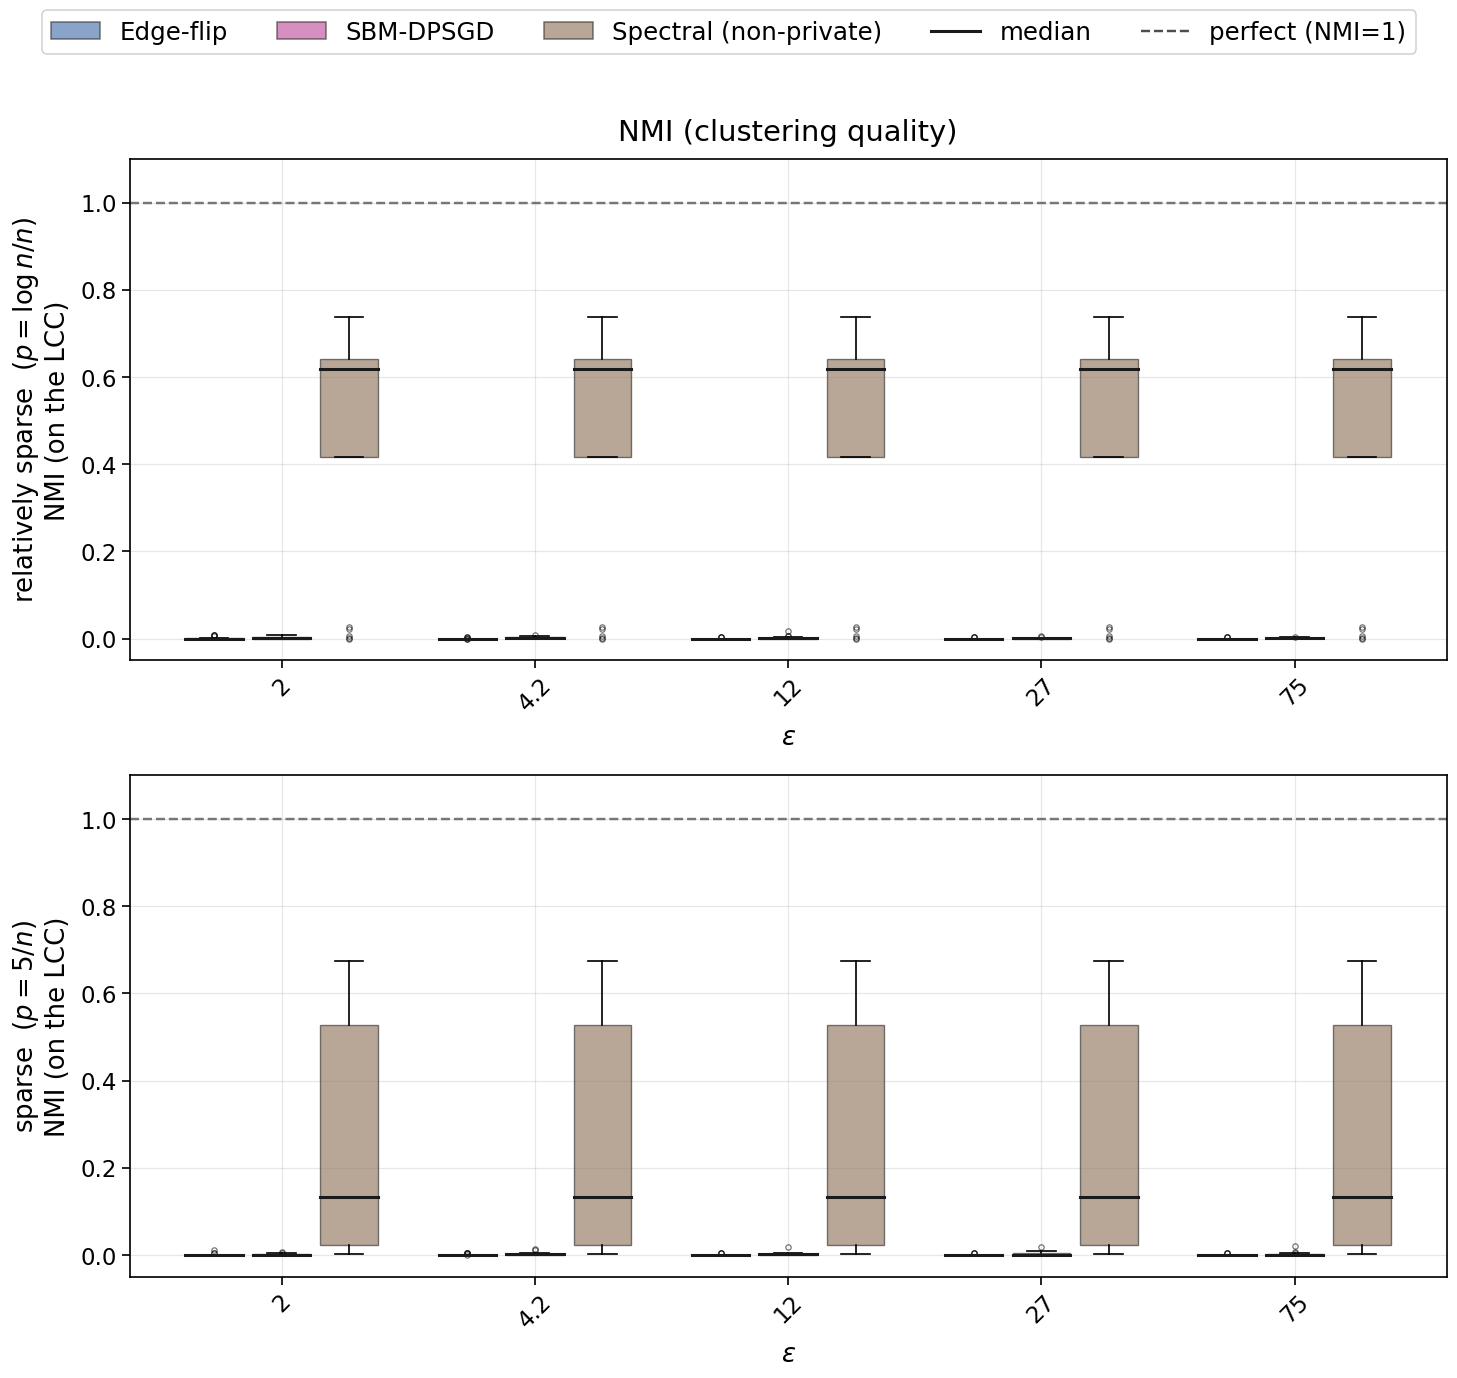

,count,mean,std,min,10%,25%,50%,75%,90%,max
regime,,,,,,,,,,
relatively_sparse,20.0,0.4704,0.2755,0.0000,0.0051,0.4174,0.6173,0.6412,0.6644,0.7370
sparse,20.0,0.2531,0.2554,0.0018,0.0164,0.0230,0.1322,0.5283,0.5639,0.6745


In [4]:

# ── Boxplots of NMI vs epsilon ─────────────────────────────────────────────
# Layout: one ROW per sparsity regime, one large panel each -- same structure
# as the beta and epochs figures, so the three read as a set. Both rows share
# the [0, 1] NMI scale.
#
# One box per method per epsilon, including the non-private spectral
# baseline: it is fit on the true LCC adjacency, so its epsilon is inf and
# epsilon_plot repeats it across the axis. Read the figure as two gaps --
# spectral box to DP box is the cost of privacy; spectral box to the NMI=1
# line is the cost of sparsity, which no method here can recover.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = METHOD_ORDER

PANEL_W, PANEL_H = 10.0, 4.6

fig, axes = plt.subplots(
    len(regimes), 1,
    figsize=figsize(PANEL_W, PANEL_H * len(regimes)),
    squeeze=False,
)

for row, regime in enumerate(regimes):
    ax = axes[row, 0]
    sub = df[df["regime"] == regime].dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", x_col="epsilon_plot", methods=methods,
                    x_values=sorted(sub["epsilon_plot"].unique()))
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(f"{REGIME_LABEL[regime]}\nNMI (on the LCC)", fontsize=17)
    if row == 0:
        ax.set_title("NMI (clustering quality)", fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="perfect (NMI=1)"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# The baseline's own spread is worth reading directly: in the sparse regime
# spectral clustering degenerates on a sizeable share of draws (it peels off a
# tiny dense pocket and NMI collapses toward 0), which is why its box there is
# so tall. The median, not the mean, is the honest summary of the ceiling.
if HAS_BASELINE:
    display(base.groupby("regime")["nmi"]
                .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
                .reindex(regimes).round(4))

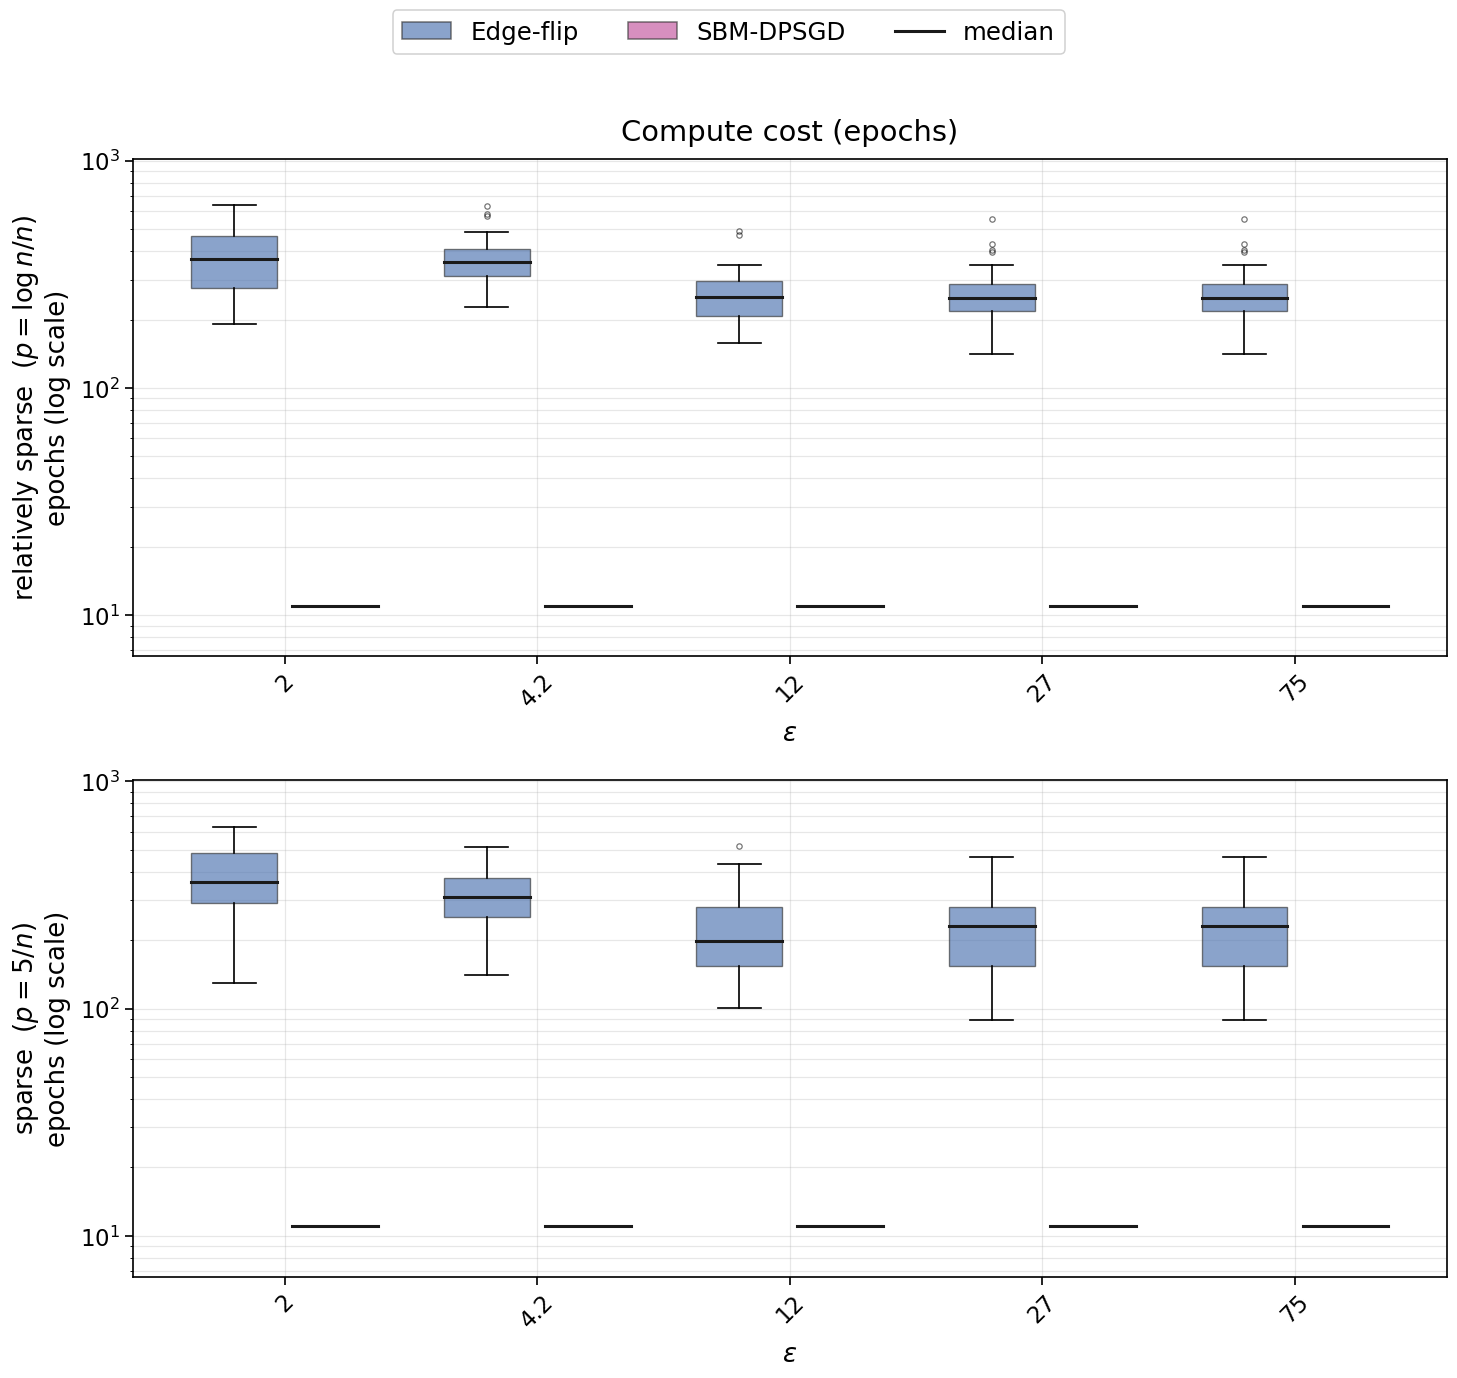

In [5]:

# ── Boxplots of # epochs (compute cost) vs epsilon ─────────────────────────
# Layout: one ROW per sparsity regime, one large panel each -- same structure
# as the beta and NMI figures. Y-limits are shared across rows so the
# regime-to-regime comparison down the column is honest.
#
# DP methods only, so the boxes are wider here than in the other figures: the
# spectral baseline is a single eigendecomposition, not an iterative fit, so
# the script records no epoch count for it. Colours still match the other
# figures method-for-method (plot_style.py).
# Log scale: the two methods differ by ~1-2 orders of magnitude, so a linear
# axis squashes the cheaper one flat against zero.
# CAVEAT (same as the other notebooks): an epoch is NOT wall-clock comparable
# across methods -- a VEM epoch is a dense O(N^2) matmul pass, an SBM-DPSGD
# epoch is a sampled per-example-autodiff pass.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, BOX_ALPHA, MEDIAN_COLOR)

apply_style()

methods = DP_METHODS

PANEL_W, PANEL_H = 10.0, 4.6

fig, axes = plt.subplots(
    len(regimes), 1,
    figsize=figsize(PANEL_W, PANEL_H * len(regimes)),
    squeeze=False,
)

ep = df.loc[df["method"].isin(methods), "epochs"].dropna()
ylim = (ep.min() * 0.6, ep.max() * 1.6)     # shared across rows (log scale)

for row, regime in enumerate(regimes):
    ax = axes[row, 0]
    sub = df[(df["regime"] == regime) & (df["method"].isin(methods))]
    grouped_boxplot(ax, sub, "epochs", x_col="epsilon_plot", methods=methods,
                    x_values=sorted(sub["epsilon_plot"].unique()))
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(f"{REGIME_LABEL[regime]}\nepochs (log scale)", fontsize=17)
    ax.grid(alpha=0.3, which="both")
    if row == 0:
        ax.set_title("Compute cost (epochs)", fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles.append(Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"))
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [6]:

# ── Summary table: median NMI and median relative beta error per cell ──────
# The baseline appears as its own row per regime (epsilon = inf, deduped to
# one row per rep), and nmi_vs_baseline gives each DP cell's median NMI minus
# the baseline median for that regime -- i.e. how far below the non-private
# ceiling that (regime, epsilon, method) lands.
import numpy as np
import pandas as pd

tbl = pd.concat([df[df["method"] != BASELINE_METHOD], base], ignore_index=True)
tbl["intra_est"] = tbl[["beta_est_00", "beta_est_11"]].mean(axis=1)
tbl["rel_err_intra"] = (tbl["intra_est"] - tbl["beta_true_00"]).abs() / tbl["beta_true_00"]
tbl["rel_err_inter"] = (tbl["beta_est_01"] - tbl["beta_true_01"]).abs() / tbl["beta_true_01"]

out = (tbl.groupby(["regime", "epsilon", "method"])
          .agg(nmi_median=("nmi", "median"),
               nmi_iqr=("nmi", lambda s: s.quantile(0.75) - s.quantile(0.25)),
               rel_err_intra_median=("rel_err_intra", "median"),
               rel_err_inter_median=("rel_err_inter", "median"),
               epochs_median=("epochs", "median"),
               n=("nmi", "size"))
          .reset_index())

if HAS_BASELINE:
    base_med = base.groupby("regime")["nmi"].median()
    out["nmi_vs_baseline"] = out["nmi_median"] - out["regime"].map(base_med)
    out.loc[out["method"] == BASELINE_METHOD, "nmi_vs_baseline"] = np.nan

out = out.round(4)
out["regime"] = pd.Categorical(out["regime"], categories=REGIME_ORDER, ordered=True)
out = out.sort_values(["regime", "epsilon", "method"]).reset_index(drop=True)
display(out)

,regime,epsilon,method,nmi_median,nmi_iqr,rel_err_intra_median,rel_err_inter_median,epochs_median,n,nmi_vs_baseline
0,relatively_sparse,1.9953,edge_flip_vem,0.0000,0.0004,0.6865,1.0000,367.5000,20,-0.6173
1,relatively_sparse,1.9953,sbm_dpsgd_all_noised,0.0009,0.0034,8.2619,3.9368,10.9999,20,-0.6164
2,relatively_sparse,4.1500,edge_flip_vem,0.0000,0.0000,0.7035,1.0000,359.5000,20,-0.6173
3,relatively_sparse,4.1500,sbm_dpsgd_all_noised,0.0009,0.0025,8.2505,4.0606,10.9999,20,-0.6164
4,relatively_sparse,11.7329,edge_flip_vem,0.0000,0.0000,0.7071,1.0000,250.5000,20,-0.6173
5,relatively_sparse,11.7329,sbm_dpsgd_all_noised,0.0009,0.0018,8.2214,4.0957,10.9999,20,-0.6164
6,relatively_sparse,27.4500,edge_flip_vem,0.0000,0.0000,0.7071,1.0000,249.0000,20,-0.6173
7,relatively_sparse,27.4500,sbm_dpsgd_all_noised,0.0007,0.0011,8.2253,4.1231,10.9999,20,-0.6166
8,relatively_sparse,75.2611,edge_flip_vem,0.0000,0.0000,0.7071,1.0000,249.0000,20,-0.6173
9,relatively_sparse,75.2611,sbm_dpsgd_all_noised,0.0012,0.0017,8.2306,4.1000,10.9999,20,-0.6161
